<a href="https://colab.research.google.com/github/sivani-tutika/RoadRecommendationSystem/blob/main/Pair_14_project1_partB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fundamentals of Artificial Intelligence**

Course code: CSCE 5210

Section: 002

Pair: 14

**Team members**

||||
|--|--|---|
|**Name:**|Naga Sai **Sivani**, Tutika| **Ketha**, Tirumuru|
|**Email:**|NagaSaiSivaniTutika@my.unt.edu|KethaTrirumuru@my.unt.edu|
|**ID:**|11703058|11597873|



### Libraries

In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

In [ ]:
import networkx as nx
import random

def CreateConnectedNetwork(N, p, L):

  '''
    N -> no. of nodes
    p -> average connectivity
    L -> range of length
  '''

  # Create an empty graph
  G = nx.Graph()

  # Add nodes to the graph
  G.add_nodes_from(range(N))

  # Ensure the graph is connected with average connectivity of p
  G = nx.erdos_renyi_graph(N, p)
  while not nx.is_connected(G):
      G = nx.erdos_renyi_graph(N, p)
      p = p + 0.1

  # Assign random lengths of range L to edges in graph G
  for edge in G.edges():
      length = random.randint(L[0], L[1])
      G.edges[edge]['weight'] = length

  return G

In [ ]:
def runSimulation(N, p, T, G, trip_list = [], H = 10):


  # no.of nodes
  N = len(G.nodes)

  # create an empty N x N array
  traffic_vol = [[0] * N for _ in range(N)]

  # if trip list is given
  if len(trip_list) > 0:


    # populate traffic_vol
    for trip in trip_list:

        # get source A and destination B
        (A, B), count = trip

        traffic_vol[A][B] += count

    print("\nStep 2: Traffic Simulation Results:")
    for i in range(N):
        print(traffic_vol[i])

    # return traffic_vol

  else:
    '''
      run simulation for H hrs.
      default: 10 Hrs
    '''

    for sec in range(0, H*60*60):

      for trip in range(0, T):

        # generate random source and destination
        A = B = 0
        while(A == B):
          A = random.randint(0,N-1)
          B = random.randint(0,N-1)

        # increment traffic volume for that pair
        traffic_vol[A][B] += 1


    print("\nStep 2: Traffic Simulation Results:")
    for i in range(N):
        print(traffic_vol[i])


  return traffic_vol

In [ ]:
def performTrafficAnalysis(G, trips, f, k, B=[]):

  # create benefit matrix
  BenefitMatrix = [[0] * len(G.nodes) for _ in range(len(G.nodes))]

  N = len(G.nodes)

  # check for each possible road X and Y in network graph G
  for X in range(N):

    for Y in range(N):

      if X == Y:
        continue

      if G.has_edge(X, Y):
        continue


      # extract neighbors of X and Y to calculate indirect benefits
      X_neighbours = list(nx.neighbors(G, X))
      Y_neighbours = list(nx.neighbors(G, Y))


      # remove X and Y as each other's neighbours if exist
      if Y in X_neighbours:
        X_neighbours.remove(Y)

      if X in Y_neighbours:
        Y_neighbours.remove(X)

      # remove common neighbours as the don't need further optimization
      for n in G.nodes:
        if (n in X_neighbours) and (n in Y_neighbours):
          X_neighbours.remove(n)
          Y_neighbours.remove(n)

      # print(f"Neighbours: X{X_neighbours}, Y: {Y_neighbours}")


      # direct benefit of road XY for trips
      # X to Y and
      # Y to X
      benefit_XY = (spd(G, X, Y) - spd(G, X, Y) * f) * (trips[X][Y] + trips[Y][X])

      # indirect benefit to X's neighbors
      # for each neighbour of X: n1
      # (spd of Y to n1) - new road length Y to X - distance of X to n1
      benefit_X_neighbours = sum(max(spd(G, Y, n1) - spd(G, X, Y) * f - spd(G, X, n1), 0) * (trips[Y][n1] + trips[n1][Y]) for n1 in X_neighbours)


      # indirect benefit to Y's neighbors
      # for each neighbour of Y: n2
      # (spd of X to n2) - new road length X to Y - distance of Y to it's neigbour n2
      benefit_Y_neighbours = sum((max(spd(G, X, n2) - spd(G, Y, X) * f - spd(G, Y, n2) , 0) * (trips[X][n2] + trips[n2][X])) for n2 in Y_neighbours)


      # update with total benefit
      BenefitMatrix[X][Y] = benefit_XY + benefit_X_neighbours + benefit_Y_neighbours

  print("\nStep 3: Benefit Matrix:")
  for i in range(len(G.nodes)):
      print(BenefitMatrix[i])

  return BenefitMatrix



In [ ]:
def findBestRoad(B,G):

  max_benefit = -1
  best_road = (-1, -1)



  for X in range(len(G.nodes)):
      for Y in range(len(G.nodes)):
        if (not G.has_edge(X, Y)) and X != Y:

            if B[X][Y] > max_benefit:
                max_benefit = B[X][Y]
                best_road = (X, Y)

  print("\nStep 4: Best Road Recommendation:")
  print("Best Road:", best_road)
  print("Max Benefit:", max_benefit)

  return best_road

In [ ]:
def spd(G:nx.Graph, X:int, Y:int):
        return nx.astar_path_length(G, source = X, target = Y, weight = 'weight')

In [ ]:
def visualizeGraph(G):

  # plt.figure(figsize=(8, 6))

  # links = [(u, v) for (u, v, d) in G.edges(data=True) if 'weight' in d]
  # pos = nx.nx_pydot.graphviz_layout(G)
  # nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', linewidths=0.25)  # draw nodes
  # nx.draw_networkx_edges(G, pos, edgelist=links, width=4)  # draw edges

  # # node labels
  # nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
  # # edge weight labels
  # edge_labels = nx.get_edge_attributes(G, 'weight')
  # nx.draw_networkx_edge_labels(G, pos, edge_labels)

  # plt.title("Final Connected Graph")
  # plt.show()

  pos= nx.nx_pydot.graphviz_layout(G)

  links = [(u, v) for (u, v, d) in G.edges(data=True) if 'weight' in d]

  # Visualize graph
  # plt.figure(figsize=(10, 10))
  nx.draw(G, with_labels=True, node_size=200,  pos = pos, node_color='skyblue', font_size=10, font_weight='bold')

  # Draw edge labels
  edge_labels = nx.get_edge_attributes(G, 'weight')
  nx.draw_networkx_edge_labels(G, pos = pos, edge_labels=edge_labels)

  plt.title('Network graph')
  plt.show()

# R2

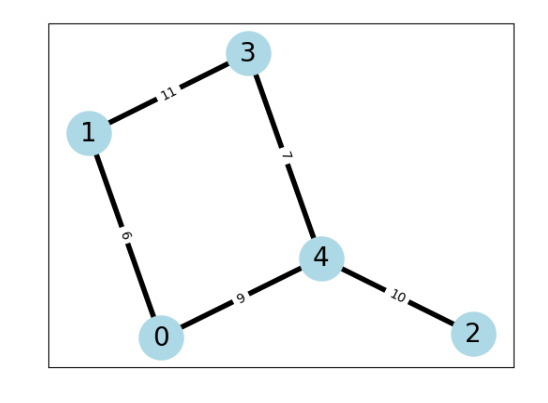

In [ ]:
N = 5
p = 0.05
T = 100
f = 0.6
k = 2
L = [5,25]

In [ ]:
# Given graph details
edges_with_weights = [(1, 3, {'weight': 11}), (3, 4, {'weight': 7}), (1, 0, {'weight': 6}),
                      (0, 4, {'weight': 9}), (4, 2, {'weight': 10})]

# Create the graph
G2 = nx.Graph()
G2.add_edges_from(edges_with_weights)

print("Step 1: Created the given graph")
print("Graph Edges with Weights:")
print(G2.edges(data=True))

# Given trip list
trip_list = [((0, 2), 1), ((2, 0), 1), ((0, 3), 1), ((3, 0), 1), ((1, 2), 1), ((2, 1), 2),
              ((1, 4), 1), ((4, 1), 2), ((2, 3), 3), ((3, 2), 1)]

Step 1: Created the given graph
Graph Edges with Weights:
[(1, 3, {'weight': 11}), (1, 0, {'weight': 6}), (3, 4, {'weight': 7}), (4, 0, {'weight': 9}), (4, 2, {'weight': 10})]


<ipython-input-23-ca731cb01148>:19: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which has known issues and is not actively maintained. Consider using nx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos= nx.nx_pydot.graphviz_layout(G)


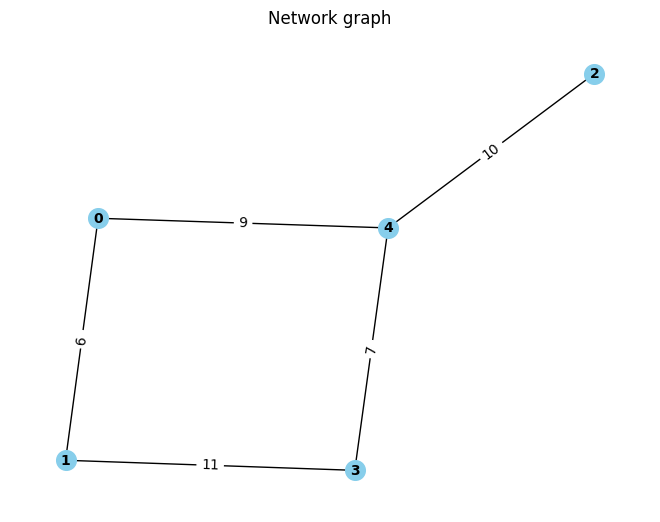

In [ ]:
visualizeGraph(G2)


Step 2: Traffic Simulation Results:
[0, 0, 1, 1, 0]
[0, 0, 1, 0, 1]
[1, 2, 0, 3, 0]
[1, 0, 1, 0, 0]
[0, 2, 0, 0, 0]

Step 2: Recommending road 1

Step 3: Benefit Matrix:
[0, 0, 38.0, 12.8, 0]
[0, 0, 30.0, 0, 36.0]
[38.0, 30.0, 0, 38.60000000000001, 0]
[12.8, 0, 38.60000000000001, 0, 0]
[0, 36.0, 0, 0, 0]

Step 4: Best Road Recommendation:
Best Road: (2, 3)
Max Benefit: 38.60000000000001
Recommended Road 1: (2, 3)
Updated Graph Edges with Weights:
[(1, 3, {'weight': 11}), (1, 0, {'weight': 6}), (3, 4, {'weight': 7}), (3, 2, {'weight': 10.2}), (4, 0, {'weight': 9}), (4, 2, {'weight': 10})]
Benefits of new roads, when k =  1
Benefit of road (0, 2) is 38.0
Benefit of road (0, 3) is 12.8
Benefit of road (1, 2) is 30.0
Benefit of road (1, 4) is 36.0
Benefit of road (2, 3) is 38.60000000000001


<ipython-input-23-ca731cb01148>:19: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which has known issues and is not actively maintained. Consider using nx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos= nx.nx_pydot.graphviz_layout(G)


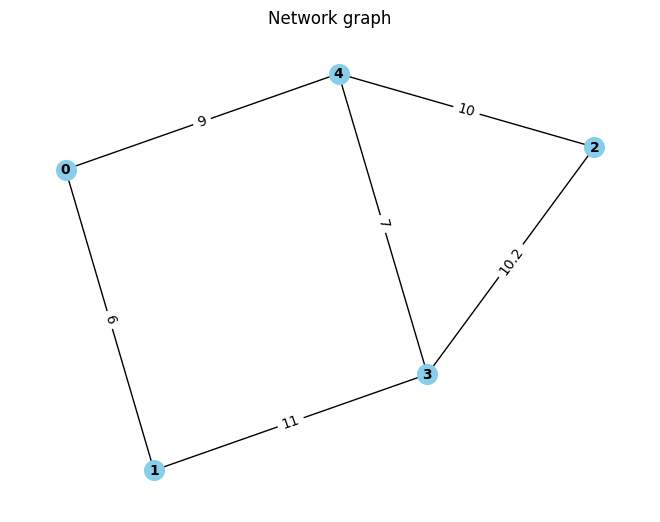


Step 3: Recommending road 2

Step 3: Benefit Matrix:
[0, 0, 26.599999999999994, 12.8, 0]
[0, 0, 26.000000000000004, 0, 24.599999999999998]
[26.599999999999994, 26.000000000000004, 0, 0, 0]
[12.8, 0, 0, 0, 0]
[0, 24.599999999999998, 0, 0, 0]

Step 4: Best Road Recommendation:
Best Road: (0, 2)
Max Benefit: 26.599999999999994
Recommended Road 2: (0, 2)
Updated Graph Edges with Weights:
[(1, 3, {'weight': 11}), (1, 0, {'weight': 6}), (3, 4, {'weight': 7}), (3, 2, {'weight': 10.2}), (4, 0, {'weight': 9}), (4, 2, {'weight': 10}), (0, 2, {'weight': 11.4})]
Benefits of new roads, when k =  2
Benefit of road (0, 2) is 26.599999999999994
Benefit of road (0, 3) is 12.8
Benefit of road (1, 2) is 26.000000000000004
Benefit of road (1, 4) is 24.599999999999998
Benefit of road (2, 3) is 0


<ipython-input-23-ca731cb01148>:19: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which has known issues and is not actively maintained. Consider using nx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos= nx.nx_pydot.graphviz_layout(G)


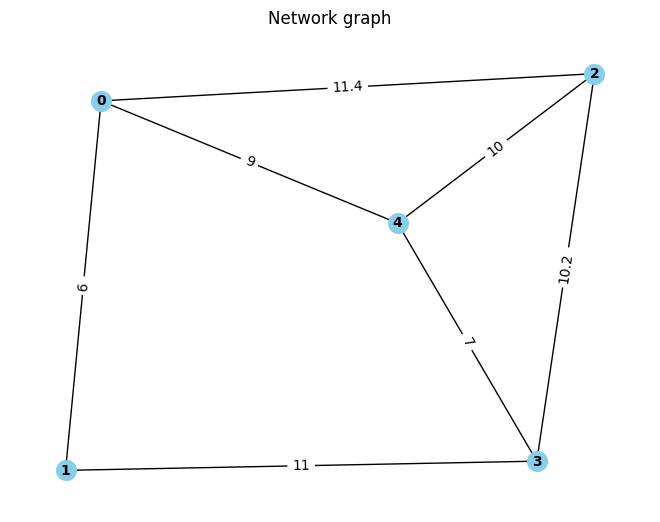

In [ ]:
# Given trip list
trip_list = [((0, 2), 1), ((2, 0), 1), ((0, 3), 1), ((3, 0), 1), ((1, 2), 1), ((2, 1), 2),
              ((1, 4), 1), ((4, 1), 2), ((2, 3), 3), ((3, 2), 1)]

traffic_vol = runSimulation(N, p, T, G2, trip_list)

# Initialize Benefit Matrix
BenefitMatrix = [[0] * len(G2.nodes) for _ in range(len(G2.nodes))]

# Initialize empty array to store k roads
roads = []
benefits = []

# Road Building Loop
for i in range(k):
    print(f"\nStep {i + 2}: Recommending road {i + 1}")
    BenefitMatrix = performTrafficAnalysis(G2, traffic_vol, f, k)
    bestRoad = findBestRoad(BenefitMatrix, G2)
    roads.append(bestRoad)
    benefits.append(BenefitMatrix[bestRoad[0]][bestRoad[1]])
    G2.add_edge(*bestRoad, weight=round(spd(G2, *bestRoad) * f,2))
    print(f"Recommended Road {i + 1}: {bestRoad}")
    print("Updated Graph Edges with Weights:")
    print(G2.edges(data=True))

    new_roads = [(0,2), (0,3), (1,2), (1,4), (2,3)]
    print('Benefits of new roads, when k = ',i+1)
    for r in new_roads:
      print(f'Benefit of road {r} is {BenefitMatrix[r[0]][r[1]]}')

    visualizeGraph(G2)

The benefit values of constructing the following new roads:
(0,2), (0,3), (1,2), (1,4), (2,3)

Use a k value (budget) of 2, which two of the above roads would you recommend for construction? Remember that once the first road is constructed, benefits that you initially computed for the other 4 will now change and these will need to be recomputed. (30 marks)

In [ ]:
print("Rocommended roads:", roads)

Rocommended roads: [(2, 3), (0, 2)]


In [ ]:
# Benefit of each road recommended
for i in range(len(roads)):
  print(f'Benefit for road {roads[i]}: {benefits[i]}')

Benefit for road (2, 3): 38.60000000000001
Benefit for road (0, 2): 26.599999999999994


# R3

To implement this requirement, you will use the program you developed in R2 with two changes. Firstly, you will replace the graph in R1 with a random graph of 60 nodes and secondly, you will use a connectivity of .05 (or nearest that gives full connectivity). Using the default values of T, k and f, your modified program should display:

The k roads that need to be constructed. You may identify these roads by their start and end points.										(20 marks)

The benefit value for each of the 3 roads that you have recommended for construction												(20 marks)

In [ ]:
N = 60
p = 0.05
L = [5, 25]
T = 100
f = 0.6
k = 3

# Create graph for R3
G3 = CreateConnectedNetwork(N, p, L)

<ipython-input-97-cc5a982fcaa3>:1: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which has known issues and is not actively maintained. Consider using nx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos= nx.nx_pydot.graphviz_layout(G3)


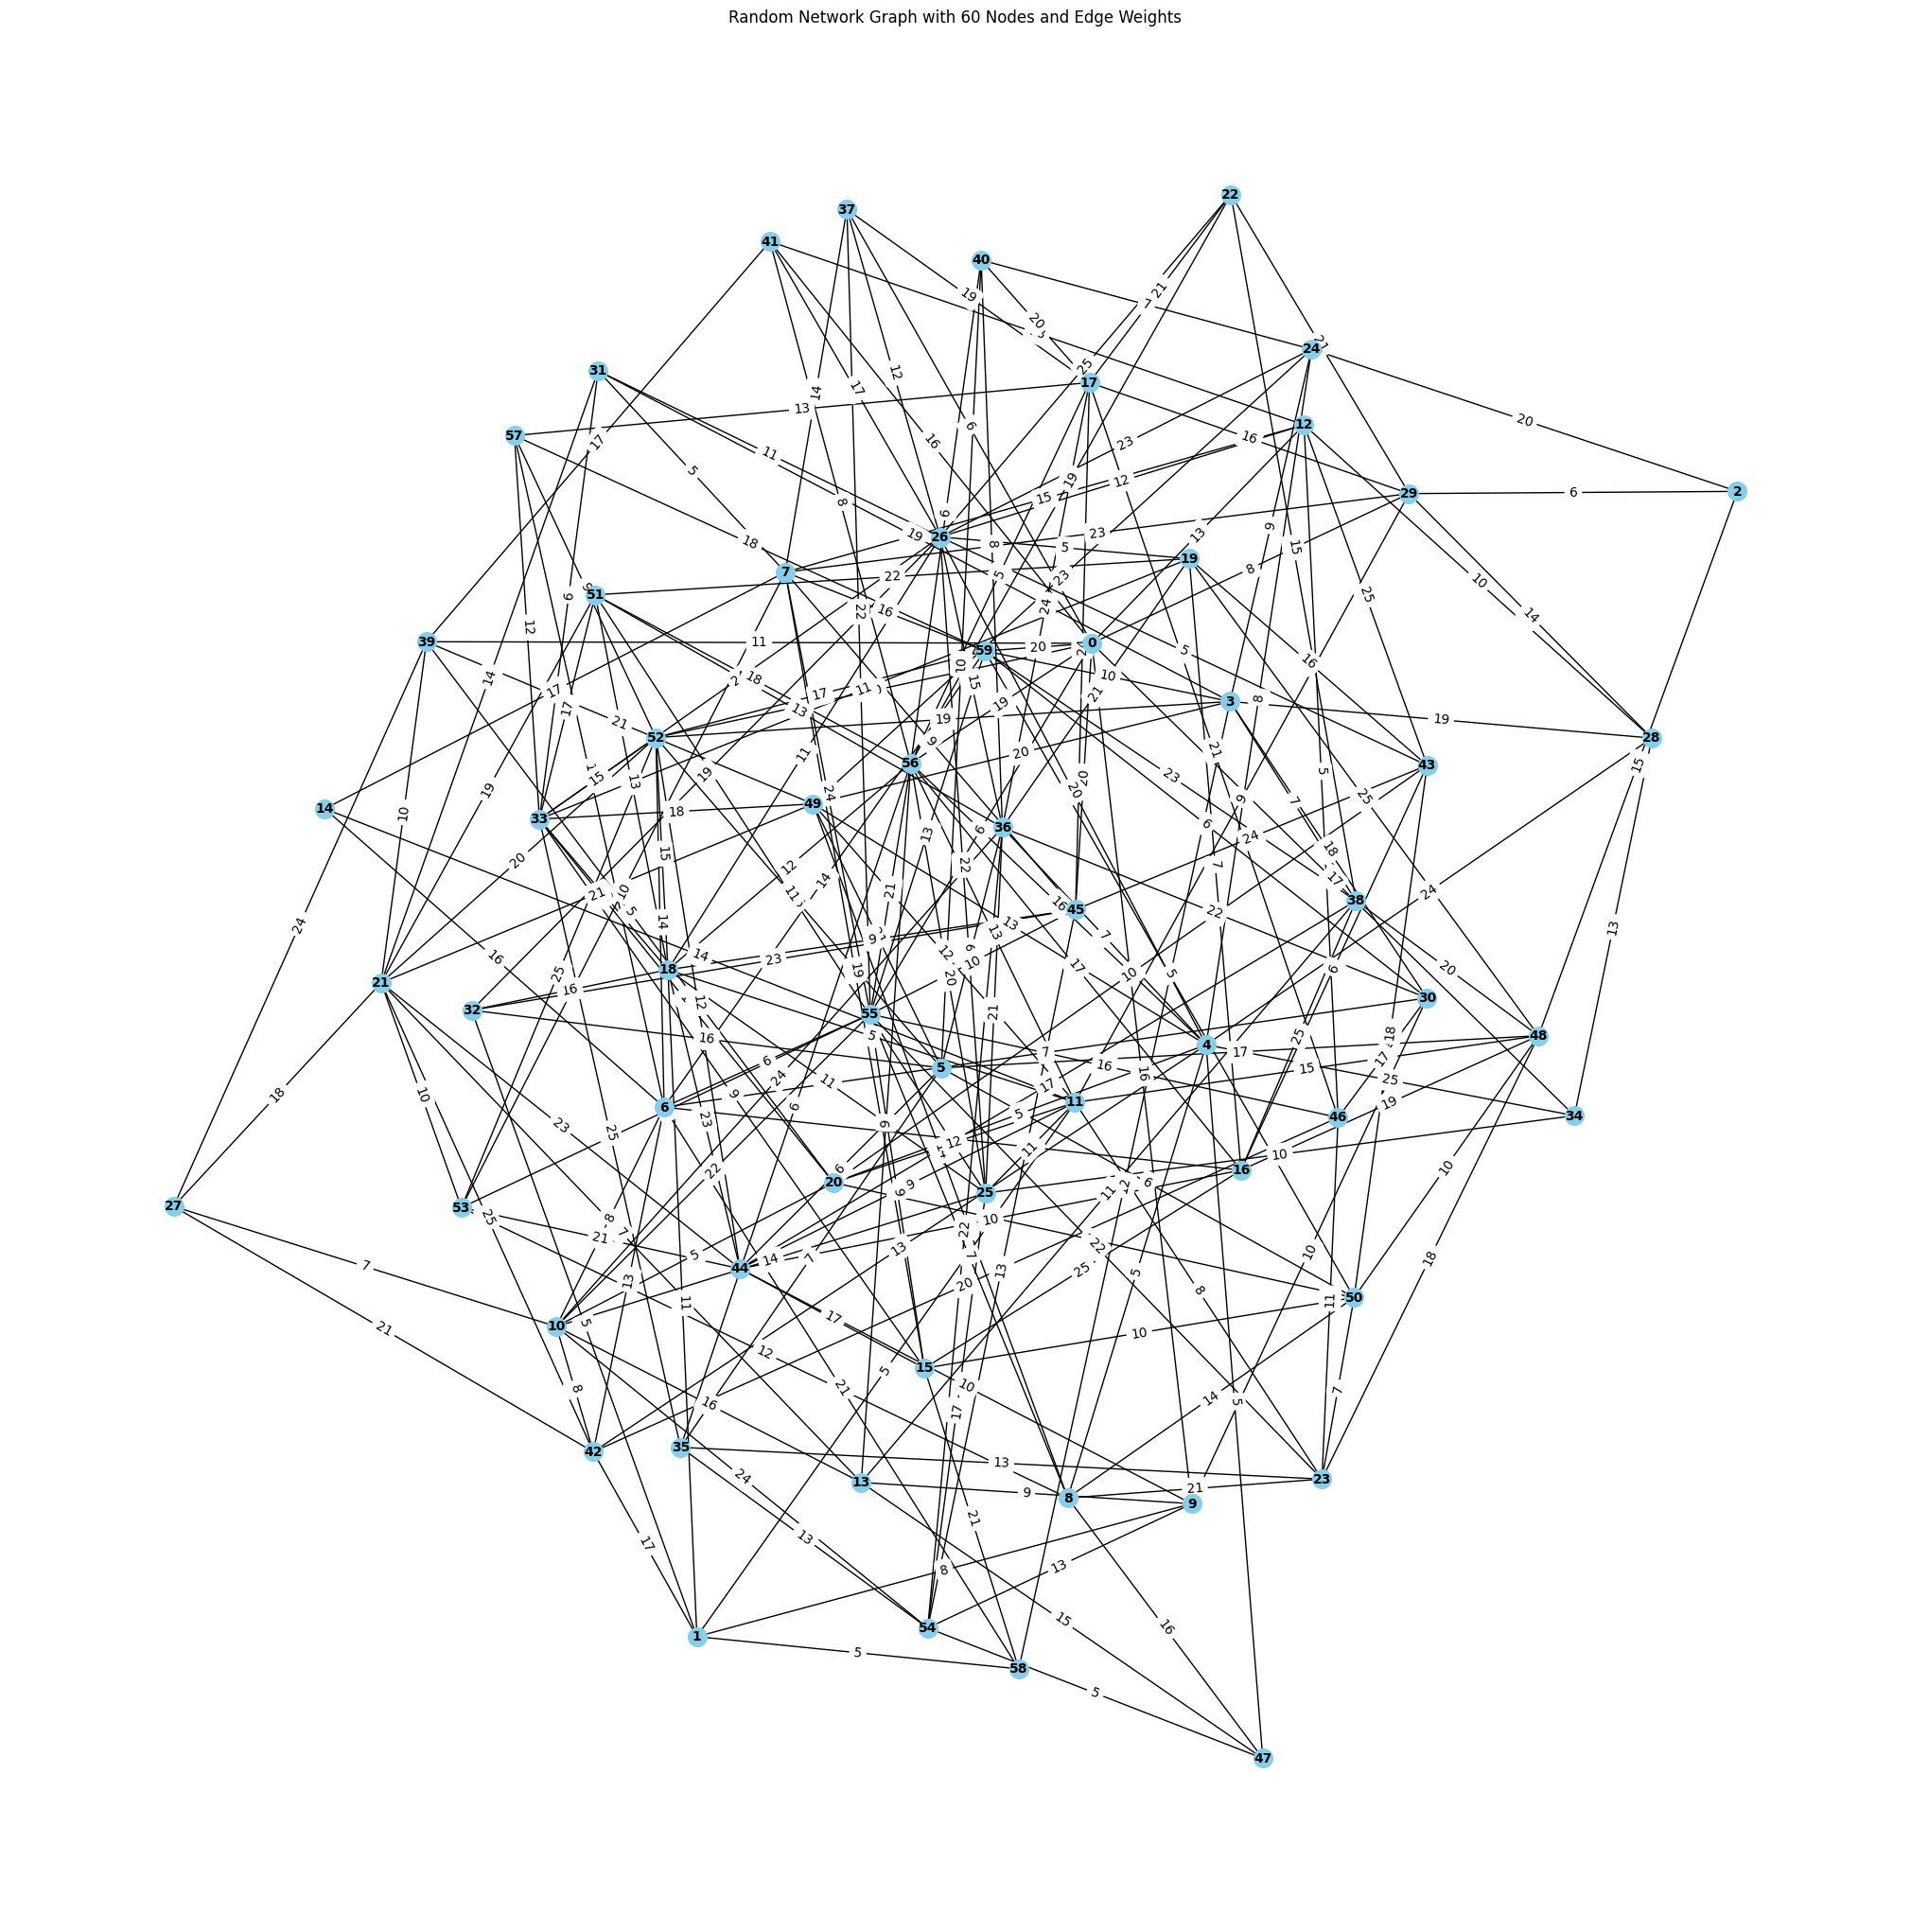

In [ ]:
pos= nx.nx_pydot.graphviz_layout(G3)

# Visualize graph
plt.figure(figsize=(20, 20))
nx.draw(G3, with_labels=True, node_size=200,  pos = pos, node_color='skyblue', font_size=10, font_weight='bold')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G3, 'weight')
nx.draw_networkx_edge_labels(G3, pos = pos, edge_labels=edge_labels)

plt.title('Random Network Graph with 60 Nodes and Edge Weights')
plt.show()

In [ ]:
# run 10 hr simulation to get traffic volume
traffic_vol = runSimulation(N, p, 100, G3)


Step 2: Traffic Simulation Results:
[0, 1051, 969, 1024, 1047, 1013, 974, 1004, 953, 1027, 1052, 1015, 990, 1051, 964, 1038, 1032, 1008, 977, 1003, 1053, 1022, 1036, 1052, 1022, 1027, 1013, 1022, 976, 1013, 1029, 1074, 1014, 997, 1043, 974, 1024, 1030, 1009, 1048, 991, 1008, 998, 991, 1022, 998, 1016, 998, 1062, 1022, 980, 971, 1076, 1011, 1039, 1006, 1047, 1033, 982, 979]
[1067, 0, 999, 1080, 973, 1024, 990, 1011, 1003, 1006, 1018, 1017, 994, 1034, 1022, 1034, 983, 1001, 968, 1028, 1007, 1047, 1019, 1002, 980, 1078, 995, 1024, 964, 1002, 1041, 1008, 1014, 1000, 984, 998, 1031, 1069, 1012, 972, 1024, 1025, 974, 993, 1038, 1040, 993, 1033, 1024, 1044, 1037, 1056, 1048, 970, 1022, 1026, 1009, 1032, 1092, 1005]
[1026, 1001, 0, 1015, 1059, 999, 1059, 1004, 1049, 1034, 1000, 987, 1048, 991, 998, 1025, 1005, 1001, 1001, 999, 978, 1000, 1052, 958, 1036, 1003, 994, 985, 1036, 1058, 963, 1018, 1053, 986, 985, 1038, 1011, 980, 1003, 1083, 1002, 1016, 957, 1063, 1028, 1060, 1011, 988, 1049, 991,

In [ ]:
# Initialize Benefit Matrix
BenefitMatrix = [[0] * len(G3.nodes) for _ in range(len(G3.nodes))]

# Initialize empty array to store k roads
roads = []
benefits=[]

# copy G3 to G4 before adding new roads to G3
G4 = G3.copy()

# Road Building Loop
for i in range(k):
    print(f"\nStep {i + 2}: Recommending road {i + 1}")
    BenefitMatrix = performTrafficAnalysis(G3, traffic_vol, f, k)
    bestRoad = findBestRoad(BenefitMatrix, G3)
    roads.append(bestRoad)
    benefits.append(BenefitMatrix[bestRoad[0]][bestRoad[1]])
    G3.add_edge(*bestRoad, weight=round(spd(G3, *bestRoad) * f,2))
    print(f"Recommended Road {i + 1}: {bestRoad}")
    # print("Updated Graph Edges with Weights:")
    # print(G3.edges(data=True))
    # visualizeGraph(G3)


Step 2: Recommending road 1

Step 3: Benefit Matrix:
[0, 99929.80000000002, 125917.00000000001, 82190.8, 114795.00000000003, 169848.0, 106473.60000000003, 88459.0, 114935.39999999998, 0, 87729.0, 122642.80000000002, 0, 110135.0, 63931.0, 116666.0, 75591.59999999999, 47869.80000000002, 48185.200000000004, 58028.20000000002, 88597.79999999999, 103173.59999999999, 177035.40000000002, 41430.0, 75732.0, 79674.0, 102147.80000000002, 91564.40000000001, 120426.00000000001, 0, 86579.40000000001, 57231.0, 67289.20000000001, 95351.80000000003, 0, 90989.00000000004, 70381.0, 0, 85431.40000000004, 0, 86792.0, 0, 69016.0, 61036.00000000002, 124000.0, 0, 80274.80000000003, 100549.20000000001, 73977.00000000003, 59977.600000000006, 74751.8, 59785.0, 0, 83032.19999999998, 83179.2, 0, 0, 127616.2, 73906.00000000001, 0]
[99929.80000000002, 0, 80088.0, 116605.6, 118956.60000000002, 84675.8, 73124.0, 117979.99999999997, 96736.20000000001, 0, 89039.00000000001, 0, 79369.60000000002, 78383.6, 63419.8, 75207

In [ ]:
print('Recommended k roads:')
roads

Recommended k roads:


[(22, 55), (11, 22), (0, 5)]

In [ ]:
print('Benefit of building k roads')
for i in range(len(roads)):

  print('Road:',roads[i])
  print('Benefit: ', benefits[i])

Benefit of building k roads
Road: (22, 55)
Benefit:  200215.0
Road: (11, 22)
Benefit:  177917.0
Road: (0, 5)
Benefit:  169848.0


# R4

Using the same data that you gathered in R3, now set f at 0.8 and display:

 The k roads that need to be constructed. You may identify these roads by their start and end points.										(5 marks)

  The benefit value for each of the 3 roads that you have recommended for construction.
										(5 marks)

Have your recommendations changed from R3? If so, why do you think they have changed?
											(10 marks)

In [ ]:
f = 0.8

# G4 = G3

# Initialize Benefit Matrix
BenefitMatrix = [[0] * len(G4.nodes) for _ in range(len(G4.nodes))]

# Initialize empty array to store k roads
roads = []
benefits=[]

# Road Building Loop
for i in range(k):
    print(f"\nStep {i + 2}: Recommending road {i + 1}")
    BenefitMatrix = performTrafficAnalysis(G4, traffic_vol, f, k)
    bestRoad = findBestRoad(BenefitMatrix, G4)
    roads.append(bestRoad)
    benefits.append(BenefitMatrix[bestRoad[0]][bestRoad[1]])
    G4.add_edge(*bestRoad, weight=round(spd(G4, *bestRoad) * f,2))
    print(f"Recommended Road {i + 1}: {bestRoad}")


Step 2: Recommending road 1

Step 3: Benefit Matrix:
[0, 45271.599999999984, 57271.999999999956, 35234.99999999998, 51512.4, 76312.59999999998, 53236.799999999974, 30651.0, 56216.8, 0, 36735.0, 51308.59999999997, 0, 42951.0, 16671.999999999993, 49170.0, 26343.199999999993, 11361.59999999999, 17388.799999999996, 20014.79999999999, 27754.599999999988, 45185.999999999985, 72280.79999999994, 20715.0, 23718.399999999994, 27616.19999999999, 39146.799999999996, 37996.59999999999, 51042.799999999974, 0, 39014.59999999998, 20360.0, 28901.79999999999, 24861.399999999976, 0, 28972.799999999974, 26305.0, 0, 29368.799999999996, 0, 19908.0, 0, 26367.0, 19716.999999999985, 46901.19999999998, 0, 36381.6, 47007.39999999998, 23663.99999999999, 24335.59999999999, 24136.599999999984, 17701.0, 0, 37022.19999999998, 35341.19999999998, 0, 0, 56407.99999999997, 21486.599999999995, 0]
[45271.599999999984, 0, 40044.0, 49541.19999999997, 52633.39999999998, 28916.799999999992, 24518.0, 46223.799999999974, 33053.

In [ ]:
print('Benefit of building k roads')
for i in range(len(roads)):

  print('Road:',roads[i])
  print('Benefit: ', benefits[i])

Benefit of building k roads
Road: (11, 22)
Benefit:  81702.0
Road: (24, 55)
Benefit:  76926.0
Road: (0, 5)
Benefit:  76312.59999999998


# R5

Now double the connectivity you used in R3. You will need to re-run the simulation as the network has changed. By how much has the benefit values for the top 3 roads to be constructed? Why do you think these values have changed?

<ipython-input-104-6d1a25f8c06b>:7: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which has known issues and is not actively maintained. Consider using nx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos= nx.nx_pydot.graphviz_layout(G5)


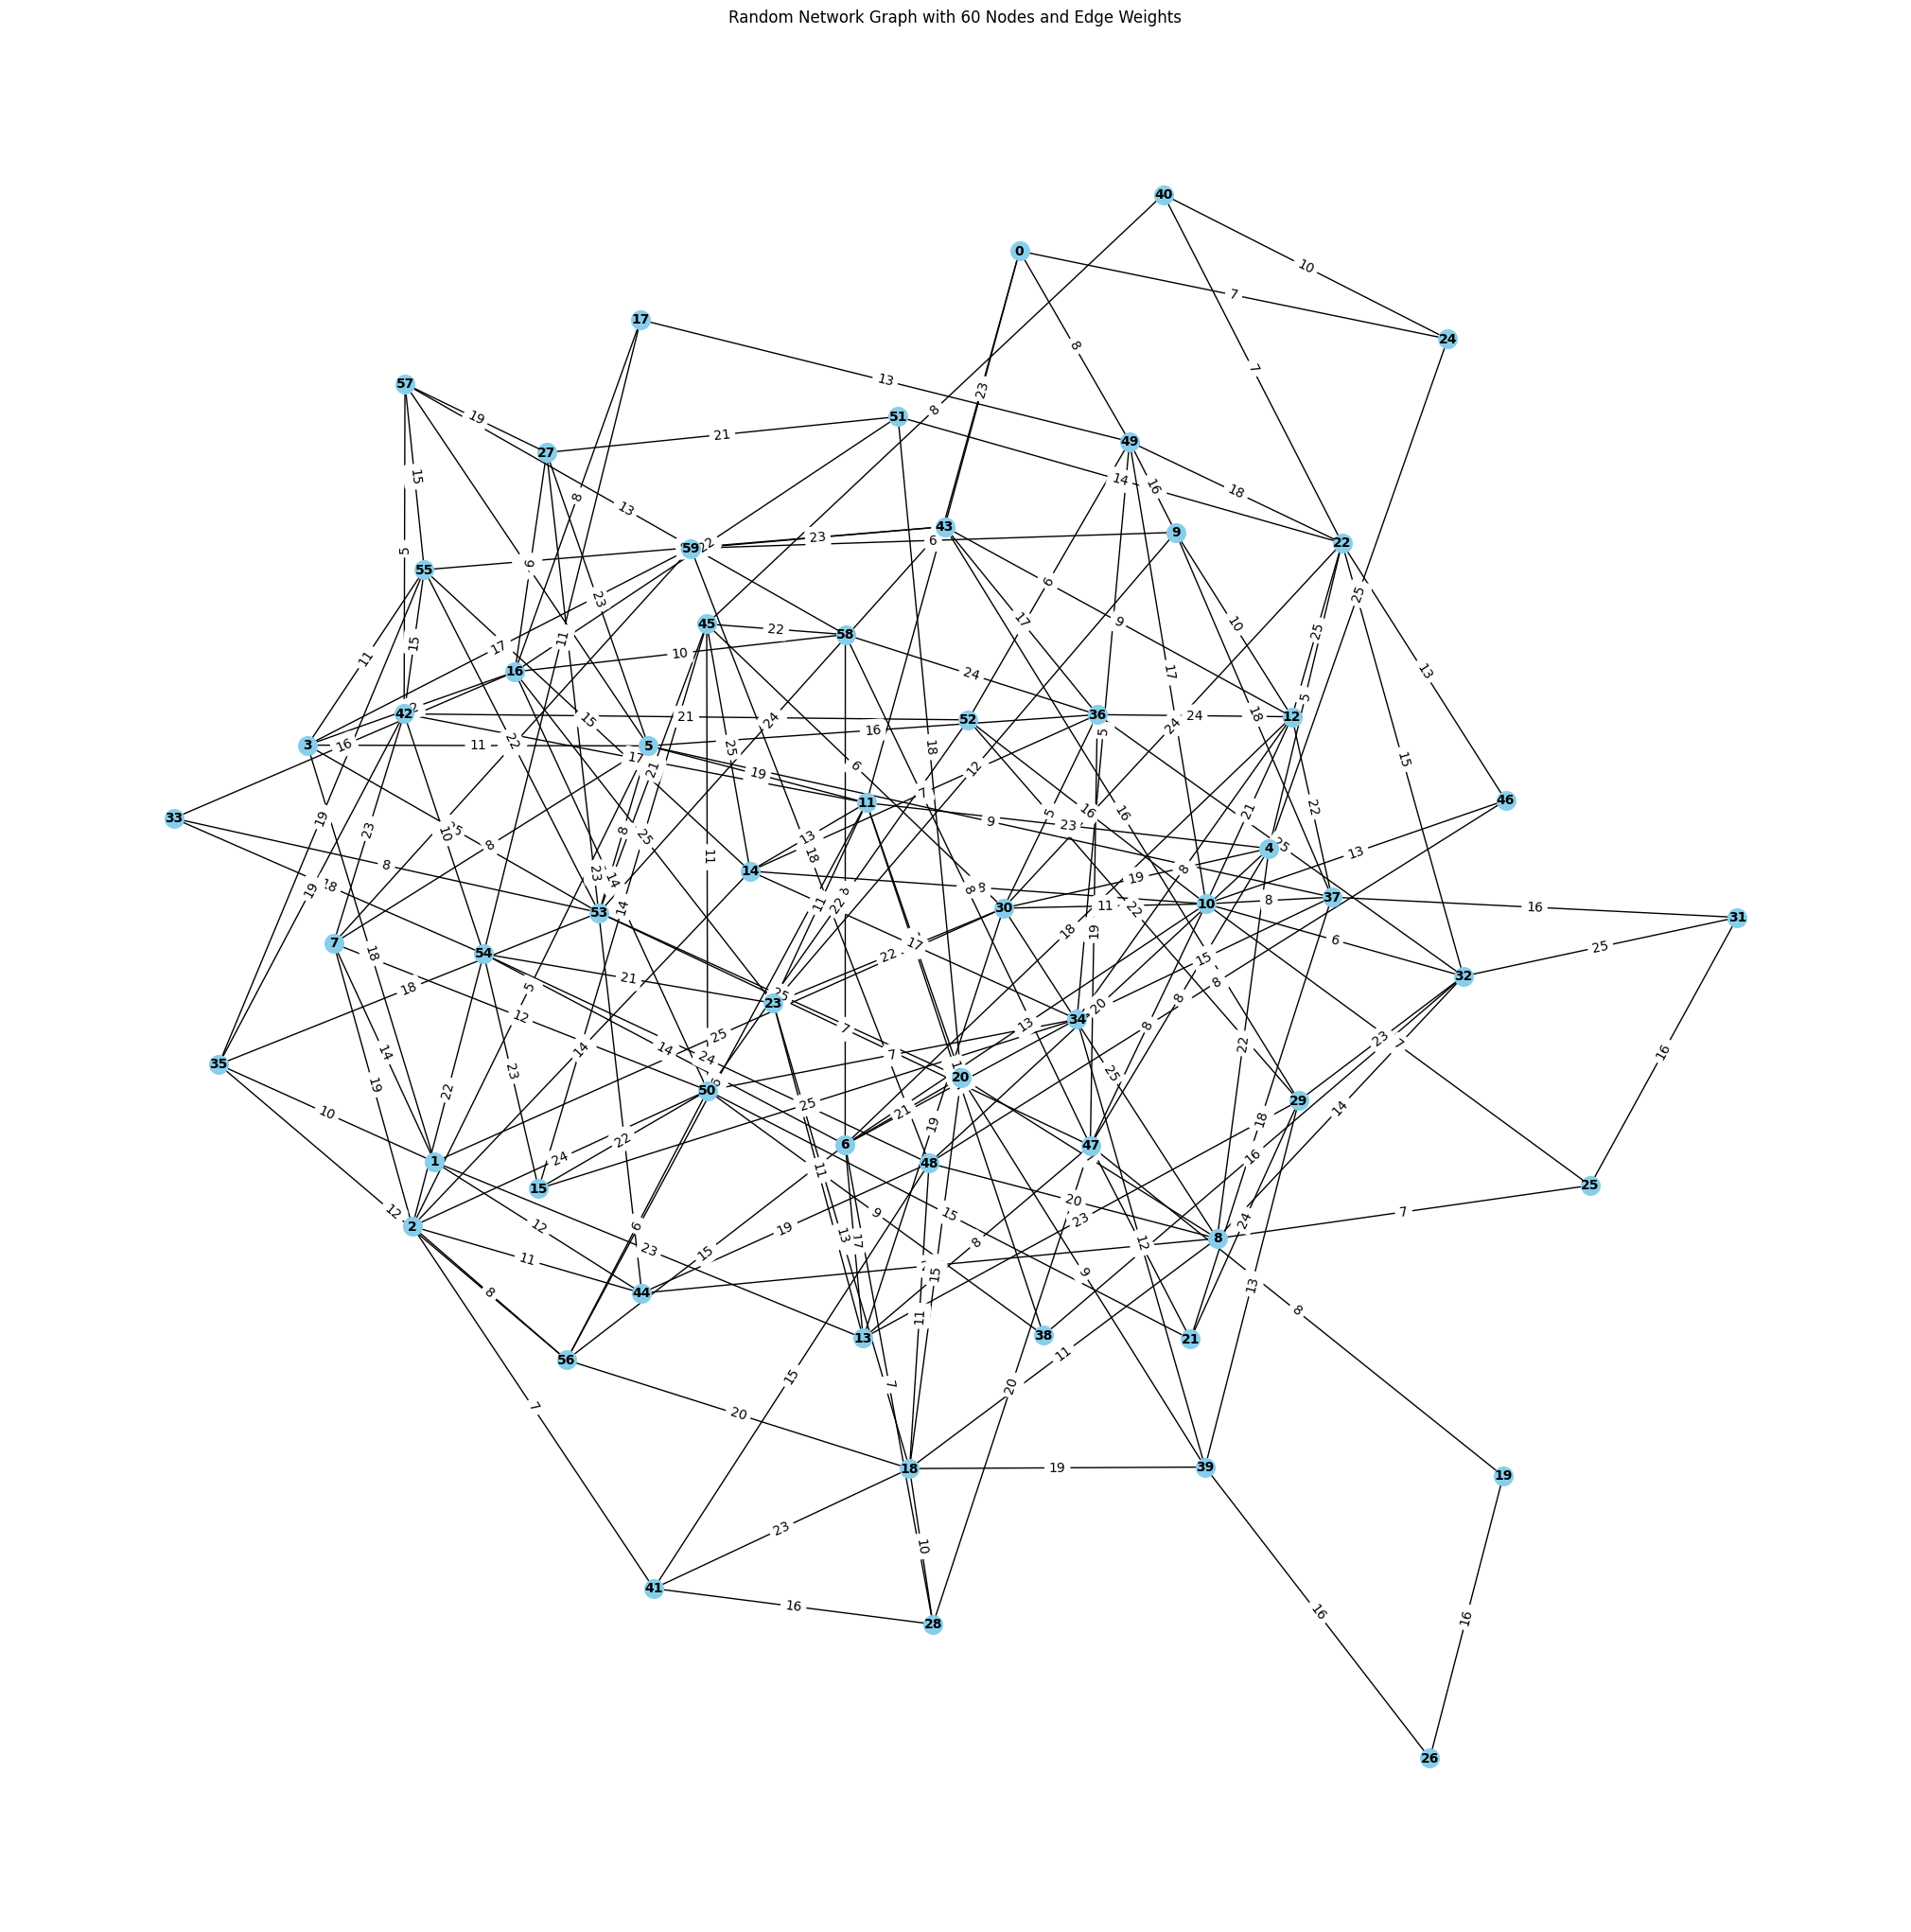

In [ ]:
p = p*2
f =0.6

# Create graph for R3
G5 = CreateConnectedNetwork(N, p, L)

pos= nx.nx_pydot.graphviz_layout(G5)

# Visualize graph
plt.figure(figsize=(20, 20))
nx.draw(G5, with_labels=True, node_size=200,  pos = pos, node_color='skyblue', font_size=10, font_weight='bold')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G5, 'weight')
nx.draw_networkx_edge_labels(G5, pos = pos, edge_labels=edge_labels)

plt.title('Random Network Graph with 60 Nodes and Edge Weights')
plt.show()

In [ ]:
# run 10 hr simulation to get traffic volume
traffic_vol = runSimulation(N, p, 100, G5)


Step 2: Traffic Simulation Results:
[0, 1025, 1063, 960, 1055, 1005, 1010, 1012, 1027, 977, 981, 1058, 1035, 1026, 1014, 1018, 993, 988, 1072, 989, 1040, 1034, 1016, 1002, 969, 1023, 1027, 983, 1036, 960, 1010, 986, 1045, 958, 1042, 1025, 1042, 944, 1054, 967, 1016, 1013, 993, 989, 1051, 1087, 976, 1025, 1006, 983, 997, 1039, 1051, 997, 998, 1018, 1058, 1027, 1048, 1037]
[1046, 0, 988, 1043, 1030, 981, 1057, 999, 1041, 977, 989, 911, 990, 1072, 997, 1029, 973, 1040, 988, 1033, 1013, 1006, 1051, 987, 1048, 1020, 1015, 995, 1002, 1039, 1045, 1022, 1044, 1007, 973, 1048, 1002, 1033, 1040, 963, 1024, 1041, 987, 1019, 975, 1050, 1013, 1051, 934, 1014, 984, 992, 1006, 957, 1010, 1015, 1022, 1003, 1034, 1020]
[1030, 1053, 0, 1073, 1062, 956, 971, 980, 1033, 993, 1014, 1060, 1032, 969, 1007, 1003, 1048, 1004, 1017, 975, 982, 996, 1003, 1047, 1051, 1071, 956, 969, 1019, 1011, 986, 1003, 1037, 1072, 1068, 990, 1064, 1025, 1029, 984, 955, 1026, 1034, 1001, 1046, 1033, 1001, 980, 1042, 1037, 1056

In [ ]:
# Initialize Benefit Matrix
BenefitMatrix = [[0] * len(G5.nodes) for _ in range(len(G5.nodes))]

# Initialize empty array to store k roads
roads = []
benefits = []

# Road Building Loop
for i in range(k):
    print(f"\nStep {i + 2}: Recommending road {i + 1}")
    BenefitMatrix = performTrafficAnalysis(G5, traffic_vol, f, k)
    bestRoad = findBestRoad(BenefitMatrix, G5)
    roads.append(bestRoad)
    benefits.append(BenefitMatrix[bestRoad[0]][bestRoad[1]])
    G5.add_edge(*bestRoad, weight=round(spd(G5, *bestRoad) * f,2))
    print(f"Recommended Road {i + 1}: {bestRoad}")


Step 2: Recommending road 1

Step 3: Benefit Matrix:
[0, 75948.0, 108045.0, 67100.8, 52265.60000000001, 116023.99999999999, 92648.4, 54657.20000000001, 107177.20000000001, 61713.60000000001, 159672.0, 0, 52123.40000000001, 77066.40000000001, 60852.0, 44179.59999999999, 122149.00000000001, 84789.6, 112309.20000000003, 61656.00000000003, 100271.0, 56032.0, 94927.00000000003, 75705.80000000002, 0, 74580.80000000002, 82480.00000000003, 68014.0, 57106.0, 69782.40000000002, 35812.60000000002, 92876.80000000002, 41655.200000000026, 73124.40000000001, 90145.6, 77608.0, 63186.0, 76654.79999999999, 43618.8, 76144.0, 75450.80000000002, 90701.79999999999, 87146.60000000002, 0, 94675.40000000001, 62408.0, 79249.0, 106718.19999999998, 68396.6, 0, 83622.0, 42907.99999999999, 46528.00000000001, 91190.80000000002, 63329.600000000006, 78008.40000000002, 74115.8, 75381.6, 55272.400000000016, 71852.0]
[75948.0, 0, 69980.60000000002, 0, 71838.00000000001, 64137.00000000001, 87608.00000000001, 0, 154795.39

In [ ]:
print('Benefit of building k roads')
for i in range(len(roads)):

  print('Road:',roads[i])
  print('Benefit: ', benefits[i])

Benefit of building k roads
Road: (18, 50)
Benefit:  201821.8
Road: (26, 50)
Benefit:  195475.0
Road: (48, 50)
Benefit:  213024.68


In [ ]:
!python -m nbconvert '/content/Pair_14_project1_partB_2.ipynb' --to html

[NbConvertApp] Converting notebook /content/Pair_14_project1_partB_2.ipynb to html
[NbConvertApp] Writing 3640489 bytes to /content/Pair_14_project1_partB_2.html
